YEHAASARY KM


CB.SC.P2AIE25032

1. Conduct an experiment to show the difference between a rule fit model and a decision tree. Visualize the decision tree and the rules generated by the rule-fit model, along with their coefficients.  give code correctly

Install Required Library

In [1]:
!pip install rulefit


  Preparing metadata (setup.py) ... done
  Created wheel for rulefit: filename=rulefit-0.3.1-py3-none-any.whl size=7798 sha256=7fe278cccaa308aa5857649020003194d2b020a91a6effcaaee6db660b981dc5
  Stored in directory: /root/.cache/pip/wheels/40/ae/a3/ad2ff0555b4b268ff64c3ed0093a3b5daf92748ff94c3e6968
Successfully built rulefit


Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

from rulefit import RuleFit


Breast Cancer Dataset

In [4]:
# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


Train Decision Tree Model

In [5]:
# Decision Tree
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

# Prediction
y_pred_dt = dt.predict(X_test)
dt_acc = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_acc)


Decision Tree Accuracy: 0.9532163742690059


Visualize the Decision Tree

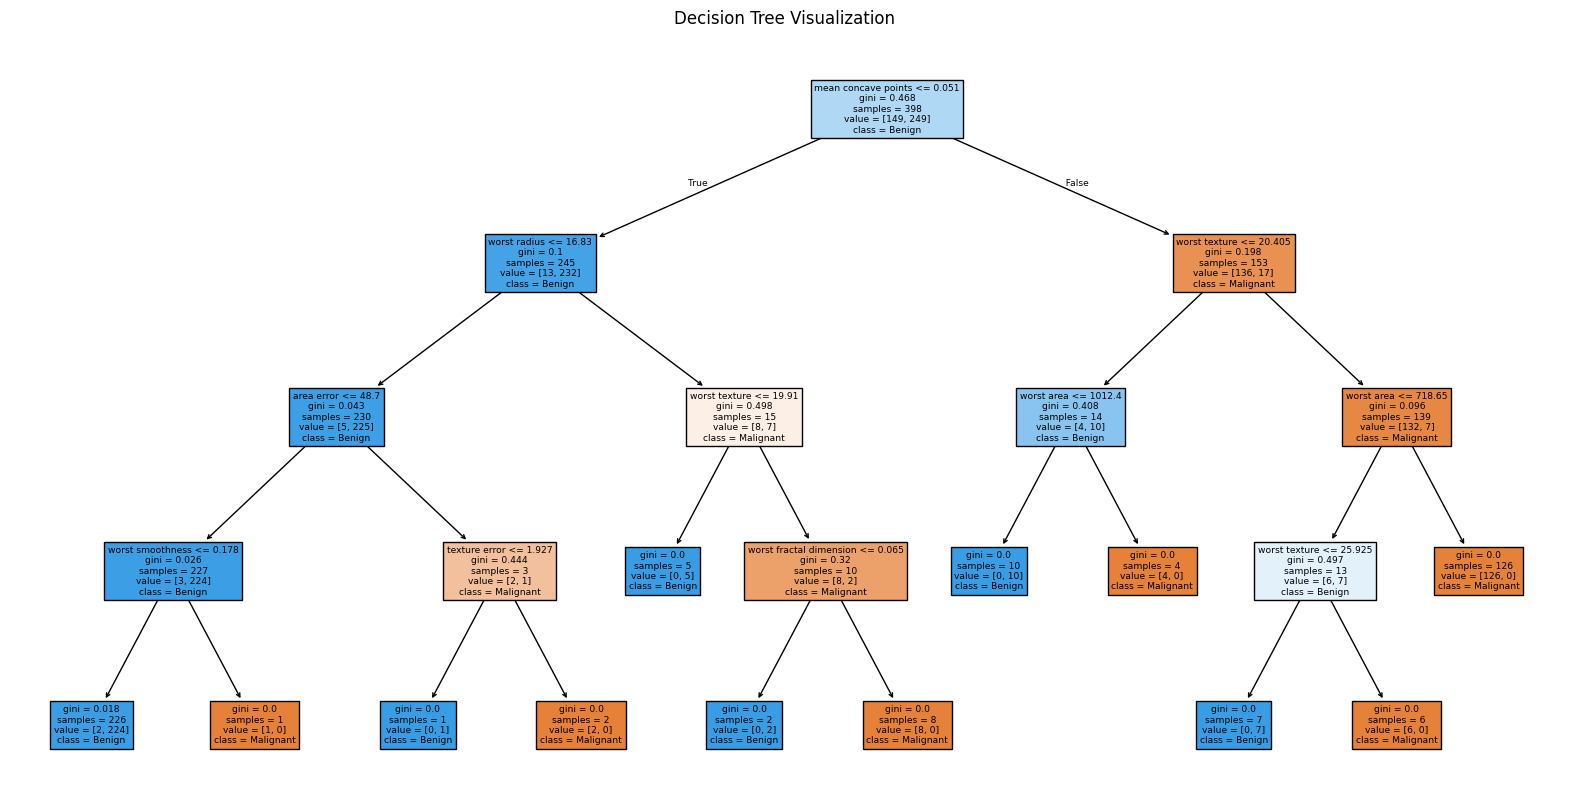

In [6]:
plt.figure(figsize=(20, 10))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["Malignant", "Benign"],
    filled=True
)
plt.title("Decision Tree Visualization")
plt.show()


This tree shows hierarchical splits

Hard to interpret when tree grows deeper

Train RuleFit Model

RuleFit:

Generates rules from trees

Uses linear model with coefficients

Keeps only important rules

In [7]:
# RuleFit model
rf = RuleFit(
    tree_size=4,
    sample_fract=0.75,
    max_rules=200,
    memory_par=0.01,
    random_state=42
)

rf.fit(X_train.values, y_train, feature_names=X.columns)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.00691861495925572, tolerance: 0.006379622641509436
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.007296602818139153, tolerance: 0.006379622641509436
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.00753766414456436, tolerance: 0.006379622641509436
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681

RuleFit(max_rules=200, random_state=42, sample_fract=0.75,
        tree_generator=GradientBoostingRegressor(learning_rate=0.01,
                                                 max_depth=100,
                                                 max_leaf_nodes=np.int64(2),
                                                 n_estimators=58,
                                                 random_state=np.int64(99),
                                                 subsample=0.5))

RuleFit Prediction & Accuracy

In [9]:
# Predict
y_pred_rf = rf.predict(X_test.values)
y_pred_rf = (y_pred_rf > 0.5).astype(int)

rf_acc = accuracy_score(y_test, y_pred_rf)
print("RuleFit Accuracy:", rf_acc)


RuleFit Accuracy: 0.9590643274853801


Extract Rules & Coefficients

In [10]:
# Get rules with coefficients
rules = rf.get_rules()

# Keep only non-zero coefficient rules
important_rules = rules[rules.coef != 0].sort_values(
    by="coef", key=abs, ascending=False
)

important_rules.head(10)


,rule,type,coef,support,importance
15,compactness error,linear,0.655352,1.000000,0.010601
97,symmetry error > 0.010375000070780516 & mean c...,rule,0.264533,0.633166,0.127489
144,worst radius > 16.824999809265137 & worst conc...,rule,-0.232532,0.030151,0.039763
65,area error > 41.53499984741211 & mean concave ...,rule,-0.188148,0.020101,0.026405
157,mean concave points <= 0.050894999876618385 & ...,rule,-0.183813,0.010050,0.018335
205,worst concave points <= 0.16125000268220901 & ...,rule,0.176302,0.678392,0.082350
201,mean concave points > 0.05048999935388565 & wo...,rule,0.162339,0.035176,0.029907
163,worst concave points > 0.1423499956727028 & me...,rule,-0.129872,0.306533,0.059878
185,mean concave points > 0.05048999935388565 & wo...,rule,-0.128005,0.336683,0.060492
117,mean concave points <= 0.05594999901950359 & w...,rule,-0.125537,0.035176,0.023127


Display Rules Clearly

In [11]:
for idx, row in important_rules.head(10).iterrows():
    print(f"Rule: {row['rule']}")
    print(f"Coefficient: {row['coef']:.4f}")
    print("-" * 60)


Rule: compactness error
Coefficient: 0.6554
------------------------------------------------------------
Rule: symmetry error > 0.010375000070780516 & mean concave points <= 0.05127999931573868 & worst smoothness <= 0.17764999717473984
Coefficient: 0.2645
------------------------------------------------------------
Rule: worst radius > 16.824999809265137 & worst concavity > 0.23935000598430634 & mean concave points <= 0.05127999931573868
Coefficient: -0.2325
------------------------------------------------------------
Rule: area error > 41.53499984741211 & mean concave points <= 0.05127999931573868 & smoothness error > 0.005083499941974878
Coefficient: -0.1881
------------------------------------------------------------
Rule: mean concave points <= 0.050894999876618385 & worst radius <= 16.824999809265137 & radius error > 0.6255500018596649
Coefficient: -0.1838
------------------------------------------------------------
Rule: worst concave points <= 0.16125000268220901 & worst radius 

Each rule is human-readable

Coefficient shows importance & direction

Positive - Benign, Negative - Malignant

**OBSERVATIONS:**

**Decision Tree**

Produces a hierarchical tree

Easy to visualize

Can become complex & overfit

All rules are used

**RuleFit**

Converts tree paths into IF–THEN rules

Applies linear model

Selects only important rules

More interpretable & sparse




| Aspect            | Decision Tree | RuleFit        |
| ----------------- | ------------- | -------------- |
| Structure         | Tree          | Linear + Rules |
| Visualization     | Tree Diagram  | Rule List      |
| Interpretability  | Medium        | High           |
| Feature Selection | No            | Yes            |
| Overfitting       | Higher        | Lower          |
